# IPL


In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading dataset
batters = pd.read_csv(r"C:\Users\KIIT\Desktop\eLabs\IPL\IPL2025Batters.csv")
bowlers = pd.read_csv(r"C:\Users\KIIT\Desktop\eLabs\IPL\IPL2025Bowlers.csv")

In [3]:
batters.head()

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37


In [4]:
bowlers.head()

,Player Name,Team,WKT,MAT,INN,OVR,RUNS,BBI,AVG,ECO,SR,4W,5W
0,Prasidh Krishna,GT,25,15,15,59.0,488,41/4,19.52,8.27,14.16,1,0
1,Noor Ahmad,CSK,24,14,14,50.0,408,18/4,17.00,8.16,12.50,2,0
2,Josh Hazlewood,RCB,22,12,12,44.0,386,33/4,17.54,8.77,12.00,1,0
3,Trent Boult,MI,22,16,16,57.4,517,26/4,23.50,8.96,15.72,1,0
4,Arshdeep Singh,PBKS,21,17,16,58.2,518,16/3,24.66,8.88,16.66,0,0


In [5]:
batters.info()
bowlers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  156 non-null    object 
 1   Team         156 non-null    object 
 2   Runs         156 non-null    int64  
 3   Matches      156 non-null    int64  
 4   Inn          156 non-null    int64  
 5   No           156 non-null    int64  
 6   HS           156 non-null    object 
 7   AVG          156 non-null    object 
 8   BF           156 non-null    int64  
 9   SR           156 non-null    float64
 10  100s         156 non-null    int64  
 11  50s          156 non-null    int64  
 12  4s           156 non-null    int64  
 13  6s           156 non-null    int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 17.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------  

In [6]:
#checking null /missing values
batters.isnull().sum()

Player Name    0
Team           0
Runs           0
Matches        0
Inn            0
No             0
HS             0
AVG            0
BF             0
SR             0
100s           0
50s            0
4s             0
6s             0
dtype: int64

In [7]:
bowlers.isnull().sum()

Player Name    0
Team           0
WKT            0
MAT            0
INN            0
OVR            0
RUNS           0
BBI            0
AVG            0
ECO            0
SR             0
4W             0
5W             0
dtype: int64

In [9]:
batters.duplicated().sum()

np.int64(0)

In [10]:
bowlers.duplicated().sum()

np.int64(0)

In [11]:
#data cleaning
batters.drop_duplicates(inplace=True)
bowlers.drop_duplicates(inplace=True)

In [12]:
batters.fillna(0, inplace=True)
bowlers.fillna(0, inplace=True)

In [17]:
# Feature engineering

In [18]:
#strike rate category
def strike_rate_category(sr):
    if sr >= 170:
        return "Explosive"
    elif sr >= 140:
        return "Aggressive"
    else:
        return "Anchor"

batters['SR_Category'] = batters['SR'].apply(strike_rate_category)

In [19]:
#boundary percentage
batters['Boundary_Runs'] = (batters['4s'] * 4) + (batters['6s'] * 6)

batters['Boundary_Percentage'] = (
    batters['Boundary_Runs'] / batters['Runs']
) * 100

In [20]:
# economy type
def economy_category(econ):
    if econ < 7:
        return "Excellent"
    elif econ < 9:
        return "Good"
    else:
        return "Expensive"

bowlers['Economy_Type'] = bowlers['ECO'].apply(economy_category)

In [21]:
#eda visualization

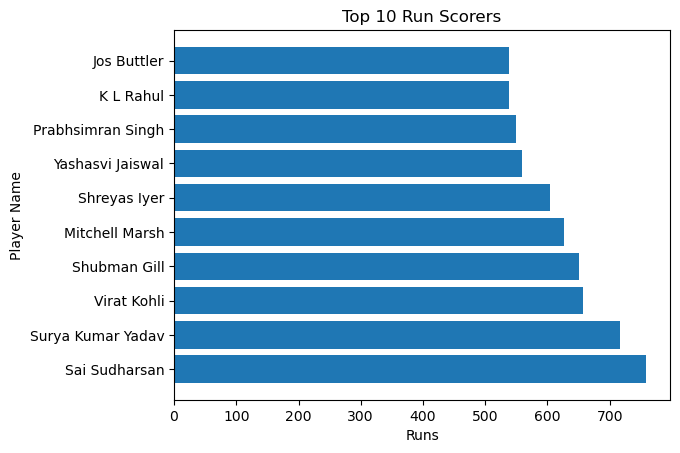

In [24]:
#top run scorrer(bar plot)
top_runs = batters.sort_values(by='Runs', ascending=False).head(10)
plt.barh(top_runs['Player Name'], top_runs['Runs'])

plt.xlabel("Runs")
plt.ylabel("Player Name")
plt.title("Top 10 Run Scorers")

plt.show()

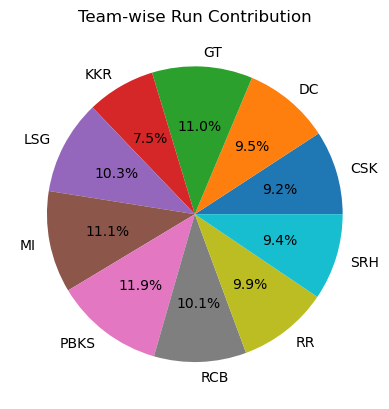

In [25]:
#team run contribution (pie chart)
team_runs = batters.groupby('Team')['Runs'].sum()
plt.pie(team_runs,labels=team_runs.index,autopct='%1.1f%%')

plt.title("Team-wise Run Contribution")

plt.show()

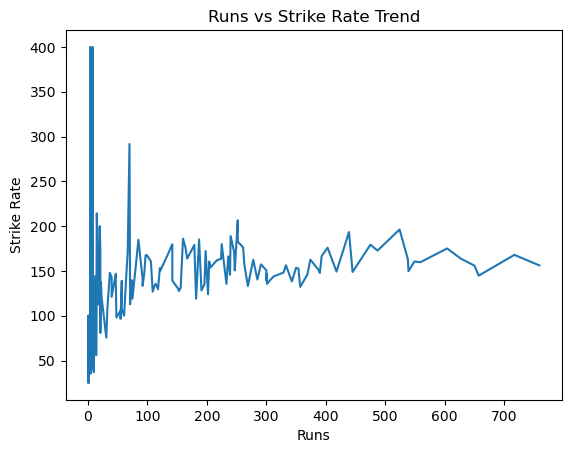

In [27]:
#strike rate trend(line plot)
sorted_batters = batters.sort_values(by='Runs')
plt.plot(sorted_batters['Runs'],sorted_batters['SR'])

plt.xlabel("Runs")
plt.ylabel("Strike Rate")

plt.title("Runs vs Strike Rate Trend")

plt.show()

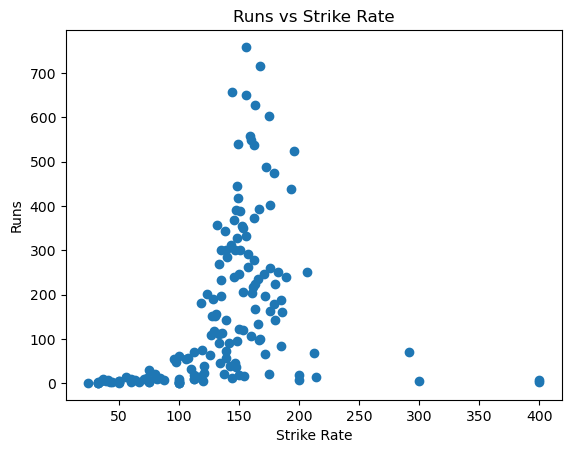

In [28]:
#runs vs strike rate(scatter plot)
plt.scatter(batters['SR'],batters['Runs'])

plt.xlabel("Strike Rate")
plt.ylabel("Runs")

plt.title("Runs vs Strike Rate")

plt.show()

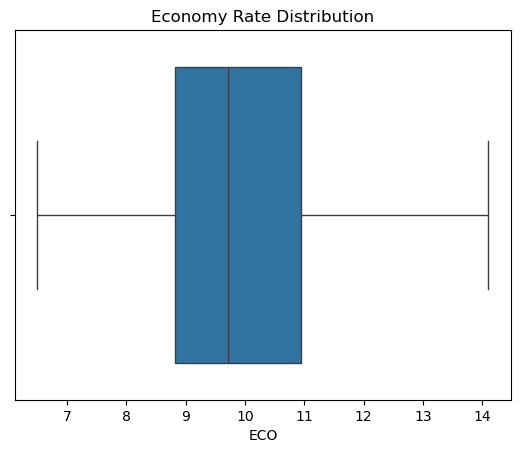

In [30]:
#Economy rate analysis (box plot)

sns.boxplot(x=bowlers['ECO'])

plt.title("Economy Rate Distribution")

plt.show()

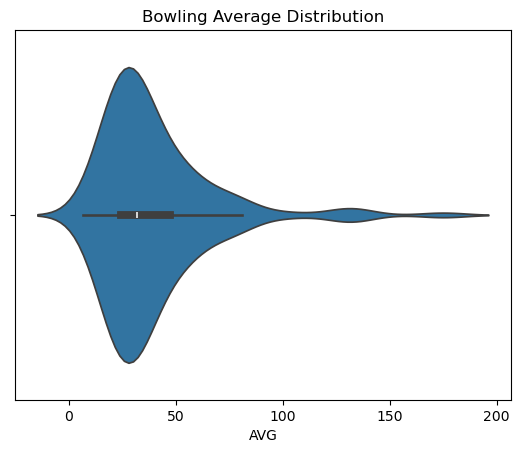

In [31]:
#Bowling avg distribution(violin plot)

sns.violinplot(x=bowlers['AVG'])

plt.title("Bowling Average Distribution")

plt.show()

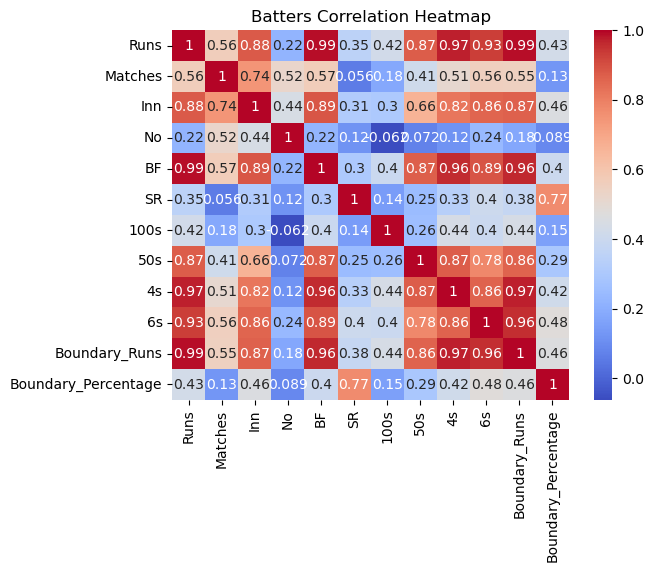

In [32]:
#heatmap

sns.heatmap(batters.corr(numeric_only=True),annot=True,cmap='coolwarm')

plt.title("Batters Correlation Heatmap")

plt.show()

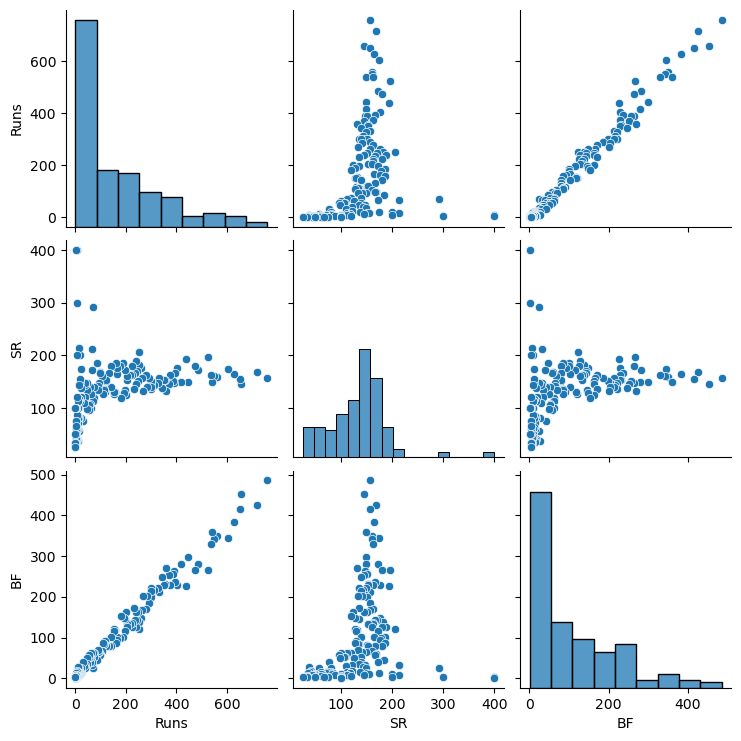

In [33]:
#pairplot
sns.pairplot(batters[['Runs', 'SR', 'AVG', 'BF']])

plt.show()

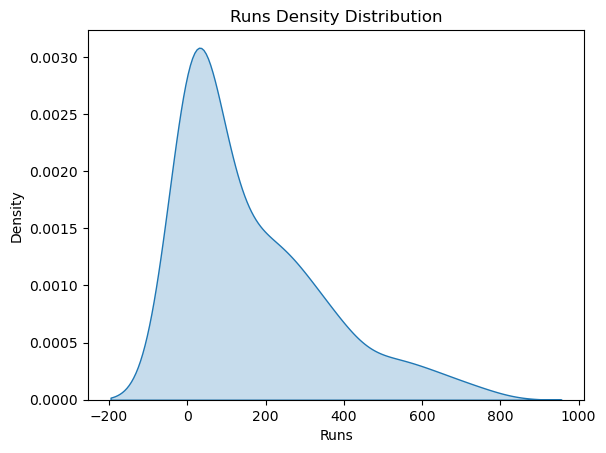

In [34]:
#KDE plot

sns.kdeplot(batters['Runs'], fill=True)

plt.title("Runs Density Distribution")

plt.show()

In [39]:

batters.replace('-', np.nan, inplace=True)

In [40]:
cols = ['Matches', 'BF', 'SR', 'AVG', 'Runs']

for col in cols:
    batters[col] = pd.to_numeric(
        batters[col],
        errors='coerce'
    )

In [41]:
batters.fillna(0, inplace=True)

In [42]:
#model training
X = batters[['Matches', 'BF', 'SR', 'AVG']]
y = batters['Runs']

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [45]:
predictions = model.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", mean_absolute_error(y_test, predictions))

print("R2 Score:", r2_score(y_test, predictions))

MAE: 15.489948710229104
R2 Score: 0.9841051902680606


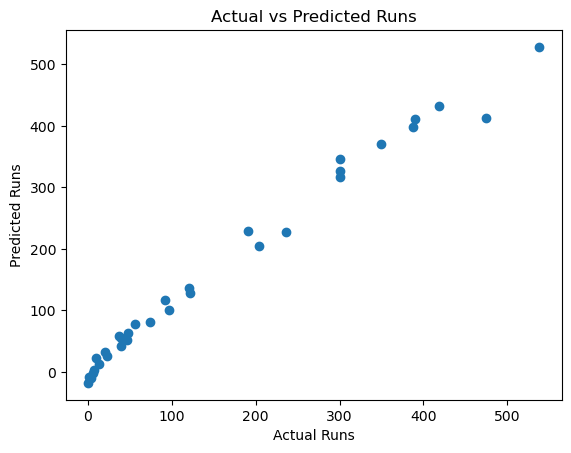

In [47]:
#actual vs predicted graph

plt.scatter(y_test, predictions)

plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")

plt.title("Actual vs Predicted Runs")

plt.show()